# Sentinel-1 GRD Product: Rectification

In [1]:
from xcube_resampling import __version__ as version

version

'0.2.5.dev0'

In [2]:
import numpy as np
import xarray as xr
from xcube.core.store import new_data_store
from xcube_resampling import affine_transform_dataset
from xcube_resampling import rectify_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt

xr.set_options(display_expand_attrs=False)

In [3]:
cluster = LocalCluster(
    n_workers=2,
    threads_per_worker=1,
    memory_limit="14GB",
    dashboard_address="8787",
)
client = Client(cluster)
client = Client(cluster)
client.dashboard_link

/home/konstantin/micromamba/envs/xcube-multistore/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35183 instead
  warnings.warn(


'http://127.0.0.1:35183/status'

In [4]:
path = (
    "data/S1A_IW_GRDH_1SDV_20251209T165439_20251209T165508_062241_07CAD4_3B2A.zarr"
)

In [5]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})

CPU times: user 115 ms, sys: 11 ms, total: 126 ms
Wall time: 123 ms


In [6]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd = grd.assign_coords(azimuth_time=(grd.azimuth_time - grd.azimuth_time[0]) / np.timedelta64(1, "s"))
grd = grd.assign_coords(ground_range=grd.ground_range / grd.sizes["ground_range"])
grd

CPU times: user 55.6 ms, sys: 12.3 ms, total: 67.8 ms
Wall time: 1.05 s


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 0.0003793 ... 9.999 10.0
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

CPU times: user 276 ms, sys: 42.8 ms, total: 319 ms
Wall time: 1.35 s


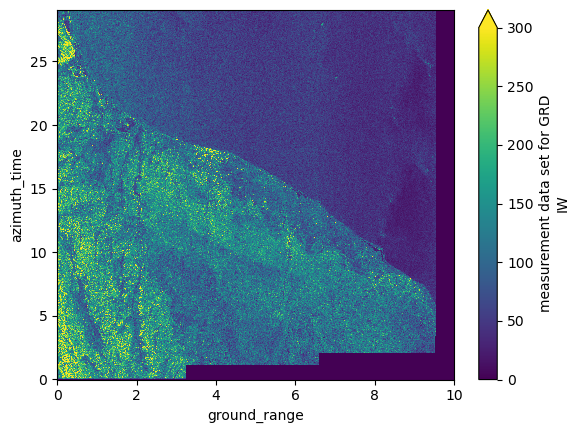

In [7]:
%%time
grd.vv[::20, ::20].plot(vmax=300)

In [8]:
%%time
gm = GridMapping.from_coords(
    grd.ground_range,
    grd.azimuth_time,
    "EPSG:3857",
    tile_size=(grd.vv.data.chunksize[1], grd.vv.data.chunksize[0]),
)
gm

CPU times: user 65.9 ms, sys: 6.83 ms, total: 72.7 ms
Wall time: 156 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: _unknown_
* crs: EPSG:3857
* xy_res: (0.000379348, 0.00149938)
* xy_bbox: (-0.0001897, -0.0007497, 9.9998103, 29.0408157)
* ij_bbox: (0, 0, 26361, 19369)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (26361, 19369)
* tile_size: (4096, 2048)

In [9]:
%%time
gcps = dt[group_VH].conditions.gcp.to_dataset()
gcps = gcps[["latitude", "longitude"]]
gcps = gcps.assign_coords(azimuth_time=(gcps.azimuth_time - gcps.azimuth_time[0]) / np.timedelta64(1, "s"))
gcps = gcps.assign_coords(ground_range=gcps.ground_range / grd.sizes["ground_range"])
gcps

CPU times: user 27.2 ms, sys: 5.93 ms, total: 33.1 ms
Wall time: 51.2 ms


<xarray.Dataset> Size: 4kB
Dimensions:       (azimuth_time: 11, ground_range: 21)
Coordinates:
  * azimuth_time  (azimuth_time) float64 88B 0.0 3.0 6.001 ... 24.0 27.0 29.04
  * ground_range  (ground_range) float64 168B 0.0 0.5 1.0 1.5 ... 9.0 9.5 10.0
    line          (azimuth_time) uint32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    pixel         (ground_range) uint32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude      (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(11, 21), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(11, 21), meta=np.ndarray>

In [10]:
%%time
dummy_ds = gcps.copy()
dummy_ds = dummy_ds.assign_coords(
    dict(
        azimuth_time=np.linspace(
            gcps.azimuth_time[0].item(),
            gcps.azimuth_time[-1].item(),
            gcps.sizes["azimuth_time"],
        ),
        ground_range=np.linspace(
            gcps.ground_range[0].item(),
            gcps.ground_range[-1].item(),
            gcps.sizes["ground_range"],
        ),
    )
)
gcps = gcps.interp_like(dummy_ds)
gcps_gm = GridMapping.from_coords(gcps.ground_range, gcps.azimuth_time, "EPSG:3857")
gcps_gm

CPU times: user 96.4 ms, sys: 12.1 ms, total: 108 ms
Wall time: 429 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: _unknown_
* crs: EPSG:3857
* xy_res: (0.499981, 2.90401)
* xy_bbox: (-0.2499905, -1.452005, 10.2496112, 30.492071)
* ij_bbox: (0, 0, 21, 11)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (21, 11)
* tile_size: (21, 11)

In [11]:
%%time
gcps_interp = affine_transform_dataset(
    gcps,
    target_gm=gm,
    source_gm=gcps_gm,
    interp_methods=1,
)
gcps_interp

CPU times: user 40.9 ms, sys: 1 ms, total: 41.9 ms
Wall time: 40.2 ms


<xarray.Dataset> Size: 8GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 0.0003793 ... 9.999 10.0
    spatial_ref   int64 8B 0
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    latitude      (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [12]:
%%time
grd = grd.assign_coords(dict(
    latitude=gcps_interp.latitude, 
    longitude=gcps_interp.longitude, 
))
grd

CPU times: user 1.81 ms, sys: 0 ns, total: 1.81 ms
Wall time: 1.43 ms


<xarray.Dataset> Size: 10GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 0.0003793 ... 9.999 10.0
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
    spatial_ref   int64 8B 0
    latitude      (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 4GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

This one sometimes work with large memeory allocated to worker. Mostly this step already fails due to memory. 

In [ ]:
%%time
grd_rect = rectify_dataset(grd, interp_methods="nearest", tile_size=2048)
grd_rect

In [ ]:
%%time
grd_rect = grd_rect.drop_vars(
    ["azimuth_time", "ground_range", "line", "pixel"]
)
grd_rect

In [ ]:
%%time
store = new_data_store("file", root="data")

If the step before works, then the writing of a subset does not work and accumulated a lot of memory. 

In [ ]:
%%time
store.write_data(
    grd_rect.isel(lat=slice(4096, 8192), lon=slice(0, 4096)),
    "sen1_rectified_sub.zarr",
    replace=True
)

In [ ]:
%%time
ds = store.open_data("sen1_rectified_sub.zarr")
ds

In [ ]:
%%time
ds.vv[::5, ::5].plot(vmax=300)